In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/saicharan2003/mnist/__results__.html
/kaggle/input/notebooks/saicharan2003/mnist/__notebook_source__.ipynb
/kaggle/input/notebooks/saicharan2003/mnist/__resultx__.html
/kaggle/input/notebooks/saicharan2003/mnist/__notebook__.ipynb
/kaggle/input/notebooks/saicharan2003/mnist/__output__.json
/kaggle/input/notebooks/saicharan2003/mnist/predictions.csv
/kaggle/input/notebooks/saicharan2003/mnist/custom.css
/kaggle/input/notebooks/saicharan2003/mnist/__results___files/__results___2_1.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TF version:", tf.__version__)

2026-06-28 15:17:50.100778: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782659870.329807      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782659870.396219      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782659870.932910      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782659870.932940      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782659870.932943      16 computation_placer.cc:177] computation placer alr

TF version: 2.19.0


In [3]:
# Internet nahi hai — tf internal cache use karenge
import tensorflow as tf
import numpy as np

# Yeh Kaggle pe cached hota hai already
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test,  -1)

print('Train:', x_train.shape)
print('Test:', x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28, 1)
Test: (10000, 28, 28, 1)


In [4]:
NOISE_FACTOR = 0.3

x_train_noisy = x_train + NOISE_FACTOR * np.random.randn(*x_train.shape)
x_test_noisy  = x_test  + NOISE_FACTOR * np.random.randn(*x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy  = np.clip(x_test_noisy,  0.0, 1.0)

print('Noisy train:', x_train_noisy.shape)

Noisy train: (60000, 28, 28, 1)


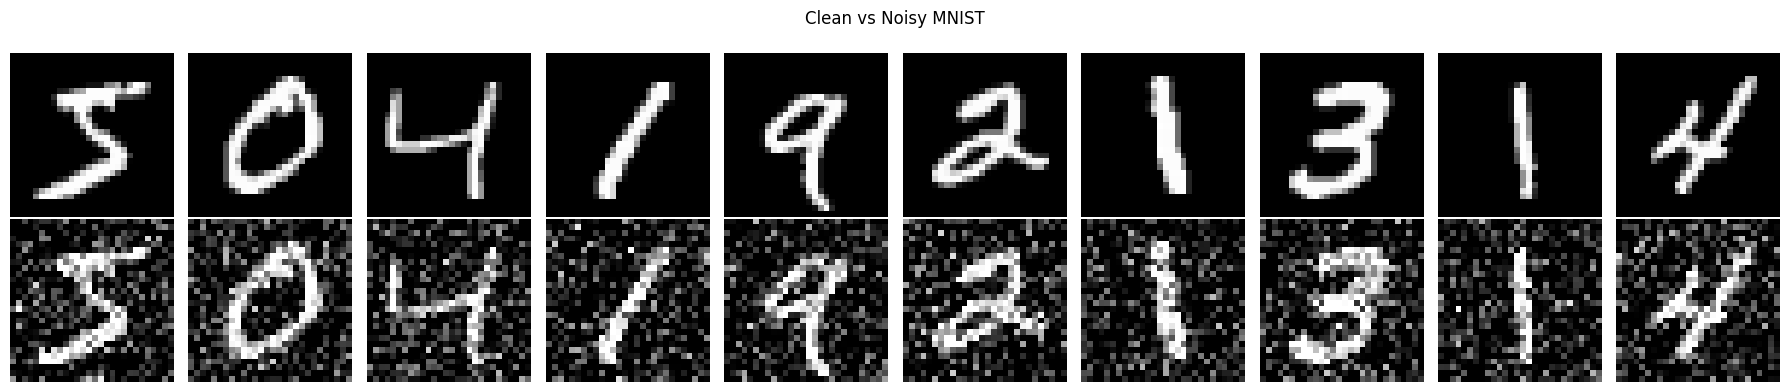

In [5]:
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for i in range(10):
    axes[0, i].imshow(x_train[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Noisy', fontsize=10)
plt.suptitle('Clean vs Noisy MNIST')
plt.tight_layout()
plt.show()

In [6]:
def build_autoencoder():
    inputs = keras.Input(shape=(28, 28, 1))

    # Encoder
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2,2), padding='same')(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)

    # Decoder
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2,2))(x)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2,2))(x)
    decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

    model = keras.Model(inputs, decoded, name='Autoencoder')
    return model

autoencoder = build_autoencoder()
autoencoder.summary()

2026-06-28 15:18:07.700595: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 108ms/step - loss: 0.1277 - val_loss: 0.0883
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - loss: 0.0864 - val_loss: 0.0834
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - loss: 0.0830 - val_loss: 0.0812
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - loss: 0.0812 - val_loss: 0.0801
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - loss: 0.0801 - val_loss: 0.0792
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 107ms/step - loss: 0.0793 - val_loss: 0.0784
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 107ms/step - loss: 0.0787 - val_loss: 0.0779
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 107ms/step - loss: 0.0782 - val_loss: 0.0776
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - loss: 0.0778 - val_loss: 0.0773
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - loss: 0.0775 - val_loss: 0.0769


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


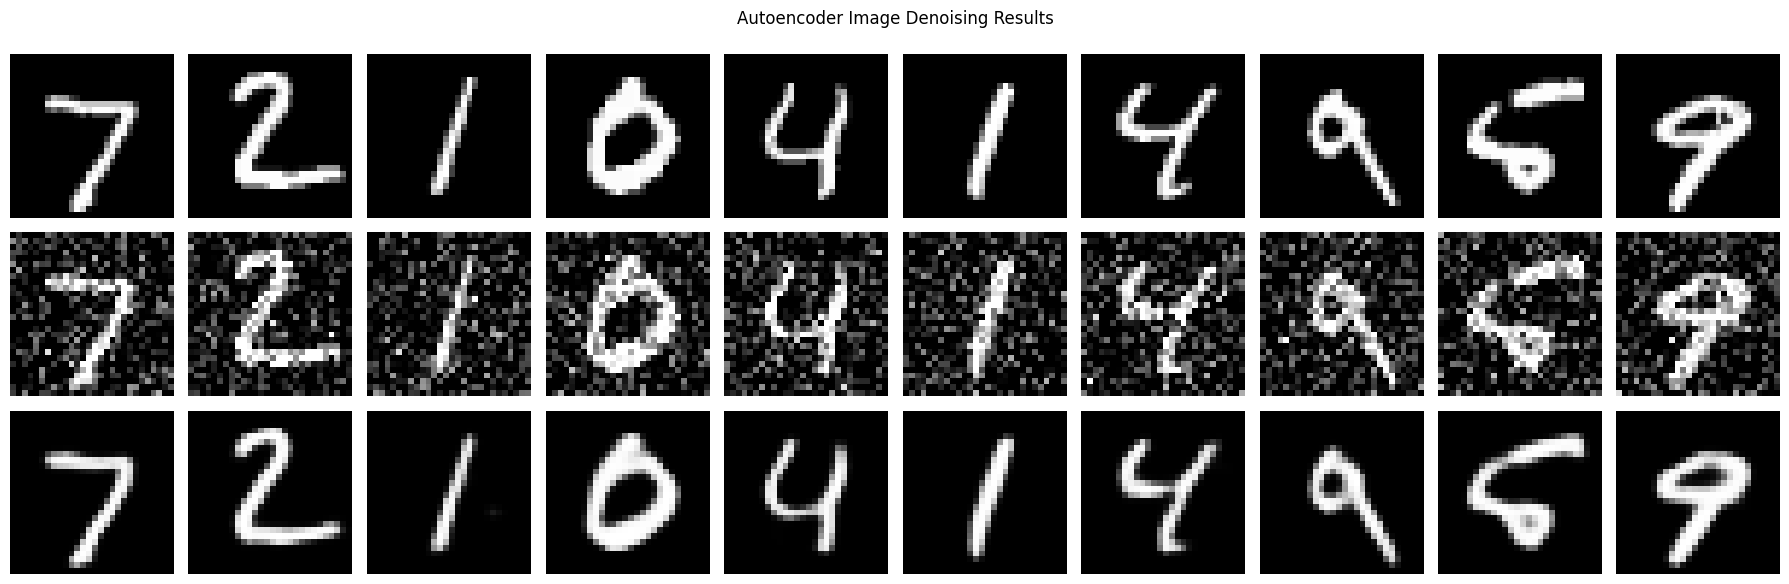

In [8]:
denoised = autoencoder.predict(x_test_noisy)

fig, axes = plt.subplots(3, 10, figsize=(18, 6))
for i in range(10):
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    axes[2, i].imshow(denoised[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Noisy', fontsize=10)
axes[2, 0].set_ylabel('Denoised', fontsize=10)
plt.suptitle('Autoencoder Image Denoising Results')
plt.tight_layout()
plt.show()

In [9]:
autoencoder.save('/kaggle/working/autoencoder_mnist.keras')
print('Model saved!')

Model saved!
